# Chapter Title Generator

**Michael Zeng, Andrew Wang, Lakshana Kathirkamaranjan, Peri Gandhi**

*Supervised BERT Encoder–Decoder (seq2seq) system that suggests creative chapter titles from narrative text.*

**How to run:** Select **Run All**. Each dataset is capped at **20,000 rows** (`MAX_ROWS_PER_DATASET` in Imports). All config, loaders, and safety logic are **inlined in this notebook** — no local `.py` files required.

| Section | Contributors |
|---------|--------------|
| Imports | Everyone |
| Load Datasets | Everyone |
| Data Cleaning | Michael, Peri |
| Exploratory Analysis | Lakshana, Andrew |
| Tokenization | Everyone |
| Train/Test Split & Model | Everyone |
| Fine-Tuning | Everyone |
| Evaluation | Everyone |
| Safety Filtering | Everyone |

---

> **Submission note:** Narrative sections and figures below count toward the page limit. Code cells in the pipeline section can be excluded when exporting to PDF if your grader allows a 20-page cap on prose only.


## 1. Problem Statement

Authors often struggle to name chapters in a way that fits tone, genre, and narrative events. Naming can interrupt creative flow and is especially difficult for new writers who lack established conventions or confidence.

We address this with a **supervised sequence-to-sequence model** that reads a passage of narrative text and proposes one or more **title candidates**. The system is instruction-tuned: the encoder receives a prefixed prompt (`generate chapter title: ...`) and the decoder generates a short title token-by-token.

**Goals:**
- Reduce friction during the writing process by offering multiple creative options.
- Learn mappings from narrative content to concise, human-like titles.
- Support multiple training corpora so team members can experiment with different text domains.


## 2. Approach

We fine-tune a **BERT Encoder–Decoder** (`EncoderDecoderModel` with `google-bert/bert-base-uncased`) using Hugging Face `Seq2SeqTrainer`.

| Component | Role |
|-----------|------|
| **Encoder** | Reads instruction-tuned narrative text and produces a contextual representation |
| **Decoder** | Generates the title autoregressively |
| **Beam search (inference)** | Returns multiple diverse title candidates |

**Instruction format**

```
Input:  generate chapter title: <narrative text>
Output: <title>
```

**Training highlights** (see Imports cell):
- Max input length 384 tokens; max target length 48 tokens
- Batch size 1 with gradient accumulation (effective batch 8)
- FP16 + gradient checkpointing for GPU memory efficiency
- Profanity filtering on training pairs and blocked-token masking at generation time


## 3. System Architecture

The pipeline has three stages: **data preparation**, **fine-tuning**, and **inference**.

## 4. Datasets

Each team member contributed a dataset loader. All loader logic is **inlined in this notebook** (no local `.py` files) and merged into one combined training pool.

| Team member | Loader (notebook) | Source | Mapping | Approx. size |
|-------------|-------------------|--------|---------|--------------|
| **Michael Zeng** | CMU loader | [CMU Book Summaries](https://huggingface.co/datasets/textminr/cmu-book-summaries) | plot summary → book title | ~16.6k |
| **Andrew Wang** | BookSum loader | [Novel Chapter / BookSum](https://github.com/manestay/novel-chapter-dataset) | study-guide summary → section title | ~9.6k train |
| **Michael Zeng** | SimpleStories loader | [SimpleStories](https://huggingface.co/datasets/SimpleStories/SimpleStories) | short story → theme | 20k cap (2.1M total) |

**CMU Book Summaries** provides book-level plot summaries paired with published titles—useful for learning high-level thematic naming.

**Novel Chapter Dataset** (via BookSum on Hugging Face) pairs classic literature chapter summaries with section names, supporting extraction of key themes from longer-form narrative summaries.

**SimpleStories** contains over two million model-generated short stories with rich metadata (`theme`, `topic`, `style`). We map **story → theme** to train on simple narrative structure and key-idea retrieval from short texts.


## 5. Data Preprocessing

Shared utilities (inlined in the Setup cells):
- **Chunking** — truncate narratives to `CHUNK_CHARS` (3,000) before tokenization
- **Instruction prefix** — prepend `generate chapter title: `
- **Deduplication** — remove duplicate (text, title) pairs
- **Train/val split** — 90/10 with configurable caps

Dataset-specific filters remove low-quality titles (e.g., generic "Chapter 3"), enforce minimum text length, and apply the safety module.


## 6. Safety

Creative writing tools should avoid offensive outputs. We implement a two-layer safety strategy:

1. **Training-time filtering** (inlined safety helpers) — `better-profanity` plus a regex blocklist scan both narrative text and target titles; unsafe pairs are dropped.
2. **Generation-time masking** — a custom `LogitsProcessor` sets logits of blocked vocabulary tokens to negative infinity during beam search.


## 7. Model & Training

| Hyperparameter | Value |
|----------------|-------|
| Encoder / Decoder | `google-bert/bert-base-uncased` |
| Epochs | 1 (smoke-test default; increase for full runs) |
| Batch size | 1 (×8 gradient accumulation) |
| Learning rate | 5e-5 |
| Max input / target length | 384 / 48 |
| FP16 | Enabled when CUDA available |

**Hardware note:** `bert-base` needs ~6 GB+ VRAM. On smaller GPUs, switch to `prajjwal1/bert-tiny` in the Imports cell (`cfg.ENCODER_MODEL` / `cfg.DECODER_MODEL`).


## 8. Inference & Evaluation

Beam search returns **multiple candidates** (`NUM_CANDIDATES=3` by default) so authors can choose among options.

**Evaluation metric:** exact string match (case-insensitive) between the top prediction and gold title on the validation set.


## 9. Results & Discussion

Title generation is inherently subjective—many valid titles exist for the same passage—so exact-match accuracy underestimates usefulness. The multi-candidate beam search interface is designed for **human-in-the-loop** selection.

**Observations:**
- CMU summaries → book titles teach high-level thematic naming.
- Novel Chapter summaries → section titles expose the model to classic literature structure.
- SimpleStories story → theme pairs emphasize concise key-idea extraction from short fiction.

**Future work:** combine datasets during training (as done in this notebook), add BLEU/ROUGE metrics, and deploy a simple web UI.


## 10. Conclusion & References

We present a BERT encoder–decoder chapter title generator with three dataset pipelines, profanity-safe training and inference, and multi-candidate beam search output.

**References**
1. CMU Book Summaries — https://huggingface.co/datasets/textminr/cmu-book-summaries
2. Ladhak et al. (2020). *Exploring Content Selection in Summarization of Novel Chapters.* ACL.
3. Kryściński et al. (2021). *BookSum: A Collection of Datasets for Long-form Narrative Summarization.*
4. Finke et al. (2025). *Parameterized Synthetic Text Generation with SimpleStories.* arXiv:2504.09184
5. Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.*

---

# Pipeline *(Run All from here)*


## Imports & Setup *(Everyone)*

The next three code cells inline configuration, data utilities, safety filtering, and all three dataset loaders — **no local Python files required**.

In [1]:
# Load HF token from .env before any Hugging Face downloads
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(Path(".").resolve() / ".env")

# pyarrow/datasets must load before torch on Windows
import datasets  # noqa: F401

import json
import random
import re
from collections import Counter
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from matplotlib.patches import FancyBboxPatch
from transformers import (
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    EncoderDecoderModel,
    LogitsProcessor,
    LogitsProcessorList,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

# --- Configuration (inlined; no config.py) ---
cfg = SimpleNamespace(
    ENCODER_MODEL="google-bert/bert-base-uncased",
    DECODER_MODEL="google-bert/bert-base-uncased",
    CHECKPOINT_DIR="checkpoints/bert2bert-titles",
    INPUT_PREFIX="generate chapter title: ",
    MAX_INPUT_LENGTH=384,
    MAX_TARGET_LENGTH=48,
    NUM_EPOCHS=1,
    BATCH_SIZE=1,
    GRAD_ACCUM_STEPS=8,
    LEARNING_RATE=5e-5,
    WEIGHT_DECAY=0.01,
    WARMUP_RATIO=0.06,
    FP16=True,
    GRADIENT_CHECKPOINTING=True,
    HYBRID_TRAIN_JSONL="seq2seq_train_hybrid.jsonl",
    HYBRID_VAL_JSONL="seq2seq_val_hybrid.jsonl",
    VAL_FRACTION=0.1,
    RANDOM_SEED=42,
    CHUNK_CHARS=3_000,
    NUM_BEAMS=4,
    NUM_CANDIDATES=3,
    MAX_GEN_LENGTH=48,
    ENABLE_PROFANITY_FILTER=True,
    BLOCKED_WORDS=(
        "damn", "hell", "shit", "fuck", "bitch", "asshole", "bastard",
    ),
)

ROOT = Path(".").resolve()
MAX_ROWS_PER_DATASET = 20_000
VAL_FRACTION = cfg.VAL_FRACTION
RANDOM_SEED = cfg.RANDOM_SEED

print(f"Project root: {ROOT}")
print(f"Max rows per dataset: {MAX_ROWS_PER_DATASET:,}")
print(f"CUDA available: {torch.cuda.is_available()}")


c:\Users\joe\Desktop\Title-Generator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\joe\Desktop\Title-Generator
Max rows per dataset: 20,000
CUDA available: True


In [2]:
# --- Data utilities & safety (inlined; no data_utils.py / safety.py) ---

def chunk_text(text: str, max_chars: int | None = None) -> str:
    max_chars = max_chars if max_chars is not None else cfg.CHUNK_CHARS
    text = text.strip()
    return text if len(text) <= max_chars else text[:max_chars]


def format_input(text: str) -> str:
    return cfg.INPUT_PREFIX + chunk_text(text)


def _row_key(row: dict) -> tuple[str, str]:
    return (row["text"].strip().lower(), row["title"].strip().lower())


def dedupe_rows(rows: list[dict]) -> list[dict]:
    seen: set[tuple[str, str]] = set()
    unique: list[dict] = []
    for row in rows:
        key = _row_key(row)
        if key in seen:
            continue
        seen.add(key)
        unique.append(row)
    return unique


def export_jsonl(rows: list[dict], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            line = json.dumps(row, ensure_ascii=False) + chr(10)
            f.write(line)


try:
    from better_profanity import profanity
    profanity.load_censor_words()
    _HAS_PROFANITY = True
except ImportError:
    _HAS_PROFANITY = False

_MAX_PROFANITY_CHARS = 512
_block_pat = r"\b(" + "|".join(re.escape(w) for w in cfg.BLOCKED_WORDS) + r")\b"
_BLOCK_RE = re.compile(_block_pat, re.I)


def contains_blocked_text(text: str) -> bool:
    if not cfg.ENABLE_PROFANITY_FILTER or not text:
        return False
    if _BLOCK_RE.search(text):
        return True
    if _HAS_PROFANITY and len(text) <= _MAX_PROFANITY_CHARS:
        return profanity.contains_profanity(text)
    return False


def is_safe_pair(text: str, title: str) -> bool:
    return not contains_blocked_text(text) and not contains_blocked_text(title)


def blocked_word_token_ids(tokenizer) -> set[int]:
    ids: set[int] = set()
    if not cfg.ENABLE_PROFANITY_FILTER:
        return ids
    for token, idx in tokenizer.get_vocab().items():
        decoded = token.replace("##", "").lower()
        if decoded in cfg.BLOCKED_WORDS:
            ids.add(idx)
    return ids

print("Data utilities and safety helpers ready.")


Data utilities and safety helpers ready.


In [3]:
# --- Dataset loaders (inlined; no data_*.py) ---

CMU_DATASET_ID = "textminr/cmu-book-summaries"
BOOKSUM_DATASET_ID = "kmfoda/booksum"
SIMPLESTORIES_DATASET_ID = "SimpleStories/SimpleStories"
CMU_PLAY_WORDS = ("scene", "act", "prologue", "epilogue")
CMU_GENERIC_CHAPTER = re.compile(r"^chapters?\s+(\d+|[ivxlcdm]+)$", re.I)
CMU_MIN_SUMMARY_CHARS = 100
BOOKSUM_MIN_TEXT_CHARS = 100
SIMPLE_MIN_STORY_CHARS = 80
SIMPLE_MIN_WORD_COUNT = 40


def _cmu_title_ok(title: str) -> bool:
    title = title.strip()
    if len(title) < 2 or len(title) > 120:
        return False
    lower = title.lower()
    if any(w in lower for w in CMU_PLAY_WORDS):
        return False
    if CMU_GENERIC_CHAPTER.match(lower):
        return False
    if lower.startswith("chapter "):
        return False
    return True


def load_cmu_book_summaries(max_rows: int | None = None) -> list[dict]:
    from datasets import load_dataset

    print(f"  loading {CMU_DATASET_ID}...", flush=True)
    ds = load_dataset(CMU_DATASET_ID, split="train")
    rows: list[dict] = []

    for i, row in enumerate(ds, 1):
        title = (row.get("title") or "").strip()
        summary = (row.get("summary") or "").strip()
        if len(summary) < CMU_MIN_SUMMARY_CHARS or not _cmu_title_ok(title):
            continue
        chunk = chunk_text(summary)
        if not is_safe_pair(chunk, title):
            continue
        rows.append({
            "text": format_input(summary),
            "title": title,
            "source": "cmu_book_summaries",
        })
        if max_rows and len(rows) >= max_rows:
            break
        if i % 2000 == 0:
            print(f"    processed {i:,}, kept {len(rows):,}", flush=True)

    return rows


def _booksum_section_title_ok(title: str) -> bool:
    title = title.strip()
    return 2 <= len(title) <= 120


def _booksum_append_row(
    rows: list[dict],
    narrative: str,
    title: str,
    source: str,
    max_rows: int | None,
) -> bool:
    narrative = narrative.strip()
    title = title.strip()
    if len(narrative) < BOOKSUM_MIN_TEXT_CHARS or not _booksum_section_title_ok(title):
        return False
    chunk = chunk_text(narrative)
    if not is_safe_pair(chunk, title):
        return False
    rows.append({
        "text": format_input(narrative),
        "title": title,
        "source": source,
    })
    return bool(max_rows and len(rows) >= max_rows)


def load_from_booksum(max_rows: int | None = None, *, use_summary: bool = True) -> list[dict]:
    from datasets import load_dataset

    print(f"  loading {BOOKSUM_DATASET_ID} (Novel Chapter / BookSum)...", flush=True)
    ds = load_dataset(BOOKSUM_DATASET_ID, split="train")
    rows: list[dict] = []

    for i, row in enumerate(ds, 1):
        title = (row.get("summary_name") or "").strip()
        narrative = (row.get("summary_text") if use_summary else row.get("chapter") or "").strip()
        if _booksum_append_row(rows, narrative, title, "novel_chapter_booksum", max_rows):
            break
        if i % 2000 == 0:
            print(f"    processed {i:,}, kept {len(rows):,}", flush=True)

    return rows


def _simple_theme_ok(title: str) -> bool:
    title = title.strip()
    return 2 <= len(title) <= 80


def load_simple_stories(max_rows: int | None = None) -> list[dict]:
    from datasets import load_dataset

    print(f"  loading {SIMPLESTORIES_DATASET_ID}...", flush=True)
    ds = load_dataset(SIMPLESTORIES_DATASET_ID, split="train", streaming=True)
    rows: list[dict] = []

    for i, row in enumerate(ds, 1):
        story = (row.get("story") or "").strip()
        theme = (row.get("theme") or "").strip()
        word_count = row.get("word_count") or 0

        if len(story) < SIMPLE_MIN_STORY_CHARS or word_count < SIMPLE_MIN_WORD_COUNT:
            continue
        if not _simple_theme_ok(theme):
            continue

        chunk = chunk_text(story)
        if not is_safe_pair(chunk, theme):
            continue

        rows.append({
            "text": format_input(story),
            "title": theme,
            "source": "simple_stories",
            "topic": (row.get("topic") or "").strip(),
        })
        if max_rows and len(rows) >= max_rows:
            break
        if i % 5000 == 0:
            print(f"    scanned {i:,}, kept {len(rows):,}", flush=True)

    return rows

print("Dataset loaders ready.")


Dataset loaders ready.


### Figure 1 — End-to-end pipeline

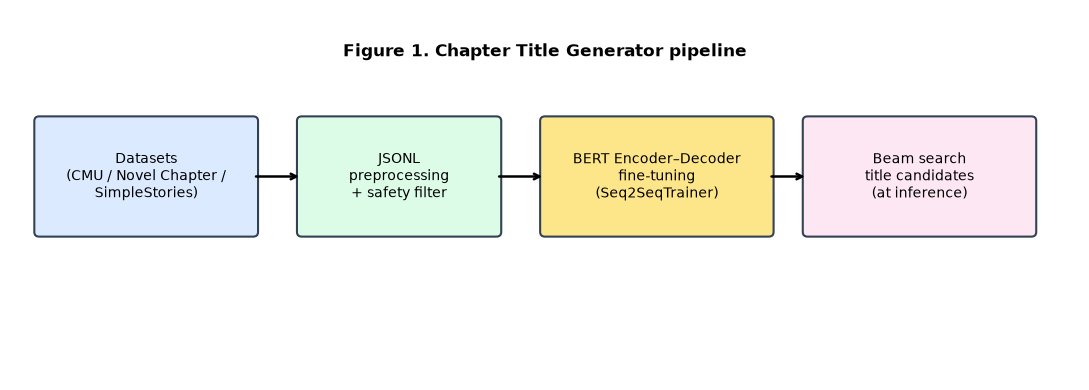

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (0.3, 1.6, 2.2, 1.2, "Datasets\n(CMU / Novel Chapter /\nSimpleStories)", "#dbeafe"),
    (3.0, 1.6, 2.0, 1.2, "JSONL\npreprocessing\n+ safety filter", "#dcfce7"),
    (5.5, 1.6, 2.3, 1.2, "BERT Encoder–Decoder\nfine-tuning\n(Seq2SeqTrainer)", "#fde68a"),
    (8.2, 1.6, 2.3, 1.2, "Beam search\ntitle candidates\n(at inference)", "#fce7f3"),
]
for x, y, w, h, text, color in boxes:
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.05",
        linewidth=1.5,
        edgecolor="#334155",
        facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10)

for x1, x2 in [(2.5, 3.0), (5.0, 5.5), (7.8, 8.2)]:
    ax.annotate("", xy=(x2, 2.2), xytext=(x1, 2.2), arrowprops=dict(arrowstyle="->", lw=1.8))

ax.text(5.5, 3.5, "Figure 1. Chapter Title Generator pipeline", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Figure 2 — Dataset scale comparison

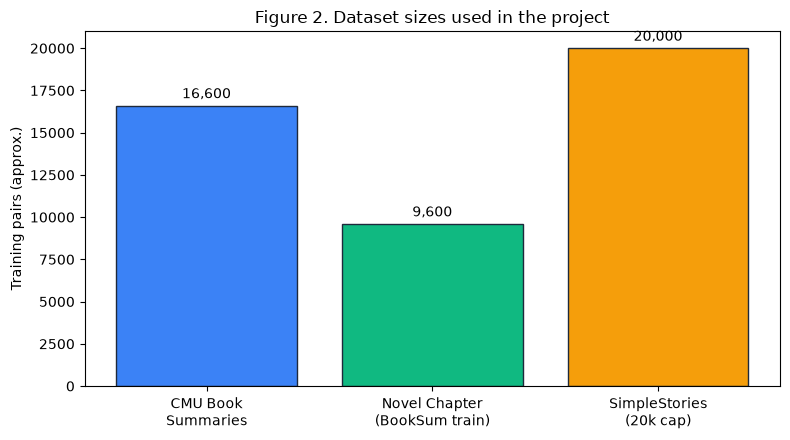

In [5]:
names = ["CMU Book\nSummaries", "Novel Chapter\n(BookSum train)", "SimpleStories\n(20k cap)"]
sizes = [16600, 9600, 20000]
colors = ["#3b82f6", "#10b981", "#f59e0b"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names, sizes, color=colors, edgecolor="#1e293b")
ax.set_ylabel("Training pairs (approx.)")
ax.set_title("Figure 2. Dataset sizes used in the project")
ax.bar_label(bars, fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

## Load Datasets *(Everyone)*

Loads all three corpora and **merges them into one hybrid dataset** (`raw_rows` → `cleaned_rows` → train/val).

| Source | Mapping |
|--------|---------|
| CMU Book Summaries | summary → book title |
| Novel Chapter / BookSum | summary → section title |
| SimpleStories | story → theme |

Saved to disk after train/val split:
- `data/seq2seq_train_hybrid.jsonl`
- `data/seq2seq_val_hybrid.jsonl`


In [6]:
print("Loading CMU Book Summaries...")
cmu_rows = load_cmu_book_summaries(MAX_ROWS_PER_DATASET)
print(f"  kept {len(cmu_rows):,} rows")

print("Loading Novel Chapter Dataset (BookSum)...")
novel_rows = load_from_booksum(MAX_ROWS_PER_DATASET)
print(f"  kept {len(novel_rows):,} rows")

print("Loading SimpleStories...")
simple_rows = load_simple_stories(MAX_ROWS_PER_DATASET)
print(f"  kept {len(simple_rows):,} rows")

raw_rows = cmu_rows + novel_rows + simple_rows
print(f"\nCombined raw rows: {len(raw_rows):,}")

Loading CMU Book Summaries...
  loading textminr/cmu-book-summaries...
    processed 2,000, kept 1,887
    processed 4,000, kept 3,764
    processed 8,000, kept 7,519
    processed 10,000, kept 9,396
    processed 12,000, kept 11,250
    processed 14,000, kept 13,055
    processed 16,000, kept 14,927
  kept 15,450 rows
Loading Novel Chapter Dataset (BookSum)...
  loading kmfoda/booksum (Novel Chapter / BookSum)...
    processed 2,000, kept 1,968
    processed 4,000, kept 3,934
    processed 6,000, kept 5,842
    processed 8,000, kept 7,688
  kept 9,220 rows
Loading SimpleStories...
  loading SimpleStories/SimpleStories...
    scanned 5,000, kept 4,999
    scanned 10,000, kept 9,996
    scanned 15,000, kept 14,990
    scanned 20,000, kept 19,988
  kept 20,000 rows

Combined raw rows: 44,670


## Data Cleaning *(Michael, Peri)*

- Remove duplicate (text, title) pairs
- Drop rows with empty or overly long titles
- Drop rows with very short narrative text
- Apply profanity / blocked-word safety filter
- Normalize instruction prefix on all inputs


In [7]:
MIN_TEXT_LEN = 80
MIN_TITLE_LEN = 2
MAX_TITLE_LEN = 120
GENERIC_CHAPTER = re.compile(r"^chapters?\s+(\d+|[ivxlcdm]+)$", re.I)
PLAY_WORDS = ("scene", "act", "prologue", "epilogue")


def clean_title(title: str) -> str | None:
    title = title.strip()
    if not (MIN_TITLE_LEN <= len(title) <= MAX_TITLE_LEN):
        return None
    lower = title.lower()
    if GENERIC_CHAPTER.match(lower) or lower.startswith("chapter "):
        return None
    if any(w in lower for w in PLAY_WORDS):
        return None
    return title


def clean_row(row: dict) -> dict | None:
    title = clean_title(row.get("title", ""))
    if not title:
        return None
    text = row.get("text", "")
    narrative = text[len(cfg.INPUT_PREFIX) :] if text.startswith(cfg.INPUT_PREFIX) else text
    narrative = narrative.strip()
    if len(narrative) < MIN_TEXT_LEN:
        return None
    chunk = chunk_text(narrative)
    if not is_safe_pair(chunk, title):
        return None
    return {
        "text": format_input(narrative),
        "title": title,
        "source": row.get("source", "unknown"),
        "topic": row.get("topic", ""),
    }


before = len(raw_rows)
cleaned_rows = [r for r in (clean_row(row) for row in raw_rows) if r]
cleaned_rows = dedupe_rows(cleaned_rows)
print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {len(cleaned_rows):,}")
print(f"Removed / deduped:    {before - len(cleaned_rows):,}")

df = pd.DataFrame(cleaned_rows)
df.head(3)

Rows before cleaning: 44,670
Rows after cleaning:  38,276
Removed / deduped:    6,394


,text,title,source,topic
0,"generate chapter title: Old Major, the old boa...",Animal Farm,cmu_book_summaries,
1,"generate chapter title: Alex, a teenager livin...",A Clockwork Orange,cmu_book_summaries,
2,generate chapter title: The text of The Plague...,The Plague,cmu_book_summaries,


## Exploratory Analysis *(Lakshana, Andrew)*

Visualize the **combined** dataset after cleaning: source distribution, title lengths, and narrative lengths.


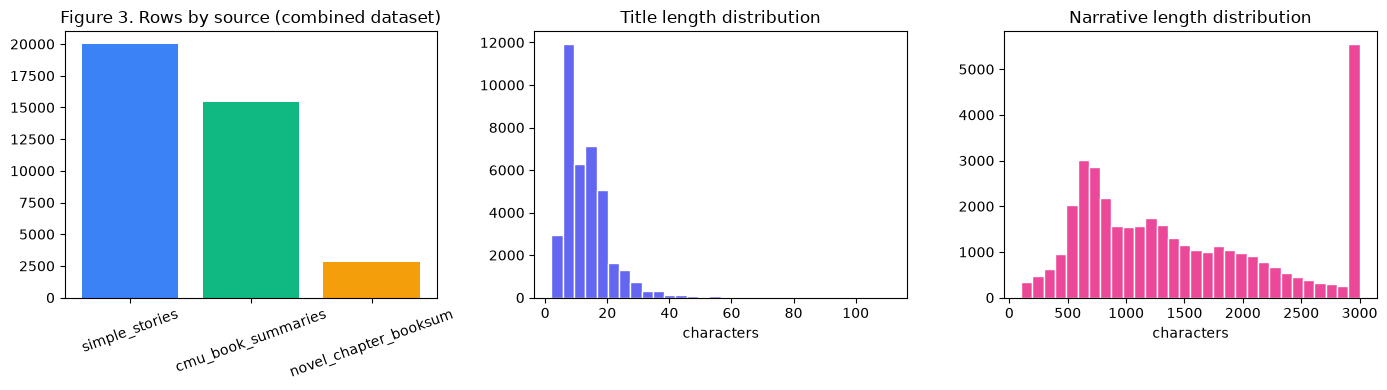

Source breakdown:
source
simple_stories           20000
cmu_book_summaries       15450
novel_chapter_booksum     2826

Sample rows:


,source,title,narrative_len
0,cmu_book_summaries,Animal Farm,3000
1,cmu_book_summaries,A Clockwork Orange,2999
2,cmu_book_summaries,The Plague,3000
3,cmu_book_summaries,An Enquiry Concerning Human Understanding,3000
4,cmu_book_summaries,A Fire Upon the Deep,3000
5,cmu_book_summaries,All Quiet on the Western Front,2999
6,cmu_book_summaries,A Wizard of Earthsea,3000
7,cmu_book_summaries,Anyone Can Whistle,2999


In [8]:
df["narrative_len"] = df["text"].str.replace(cfg.INPUT_PREFIX, "", regex=False).str.len()
df["title_len"] = df["title"].str.len()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

source_counts = df["source"].value_counts()
palette = ["#3b82f6", "#10b981", "#f59e0b", "#a855f7", "#ef4444"]
axes[0].bar(source_counts.index, source_counts.values, color=palette[: len(source_counts)])
axes[0].set_title("Figure 3. Rows by source (combined dataset)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(df["title_len"], bins=30, color="#6366f1", edgecolor="white")
axes[1].set_title("Title length distribution")
axes[1].set_xlabel("characters")

axes[2].hist(df["narrative_len"], bins=30, color="#ec4899", edgecolor="white")
axes[2].set_title("Narrative length distribution")
axes[2].set_xlabel("characters")

plt.tight_layout()
plt.show()

print("Source breakdown:")
print(source_counts.to_string())
print("\nSample rows:")
display(df[["source", "title", "narrative_len"]].head(8))

## Tokenization

Load the BERT tokenizer and define preprocessing for seq2seq fine-tuning.

In [9]:
def preprocess_rows(rows, tokenizer, max_input=cfg.MAX_INPUT_LENGTH, max_target=cfg.MAX_TARGET_LENGTH):
    inputs = [r["text"] for r in rows]
    targets = [r["title"] for r in rows]
    model_inputs = tokenizer(inputs, max_length=max_input, truncation=True, padding=False)
    labels = tokenizer(text_target=targets, max_length=max_target, truncation=True, padding=False)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


class TitleDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}


tokenizer = AutoTokenizer.from_pretrained(cfg.ENCODER_MODEL)
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
sample = preprocess_rows(cleaned_rows[:2], tokenizer)
print(f"Sample input tokens: {len(sample['input_ids'][0])}")
print(f"Sample label tokens: {len(sample['labels'][0])}")

Tokenizer vocab size: 30,522
Sample input tokens: 384
Sample label tokens: 4


## Train/Test Split & Model Construction

Shuffle the cleaned data, split into train/validation, tokenize each split, and build the BERT encoder–decoder.


In [10]:
rows = cleaned_rows.copy()
random.seed(RANDOM_SEED)
random.shuffle(rows)

val_size = max(1, int(len(rows) * VAL_FRACTION))
val_rows = rows[:val_size]
train_rows = rows[val_size:]

print(f"Train rows: {len(train_rows):,}")
print(f"Val rows:   {len(val_rows):,}")


hybrid_train_path = ROOT / "data" / cfg.HYBRID_TRAIN_JSONL
hybrid_val_path = ROOT / "data" / cfg.HYBRID_VAL_JSONL
export_jsonl(train_rows, hybrid_train_path)
export_jsonl(val_rows, hybrid_val_path)
print(f"Saved hybrid train -> {hybrid_train_path}")
print(f"Saved hybrid val   -> {hybrid_val_path}")


train_enc = preprocess_rows(train_rows, tokenizer)
val_enc = preprocess_rows(val_rows, tokenizer)
train_ds = TitleDataset(train_enc)
val_ds = TitleDataset(val_enc)

model = EncoderDecoderModel.from_encoder_decoder_pretrained(cfg.ENCODER_MODEL, cfg.DECODER_MODEL)
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
model.generation_config.decoder_start_token_id = tokenizer.cls_token_id
model.generation_config.eos_token_id = tokenizer.sep_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.max_length = cfg.MAX_TARGET_LENGTH
model.generation_config.num_beams = cfg.NUM_BEAMS

if cfg.GRADIENT_CHECKPOINTING and hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
print("Model and datasets ready.")


Train rows: 34,449
Val rows:   3,827
Saved hybrid train -> C:\Users\joe\Desktop\Title-Generator\data\seq2seq_train_hybrid.jsonl
Saved hybrid val   -> C:\Users\joe\Desktop\Title-Generator\data\seq2seq_val_hybrid.jsonl


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3290.51it/s]
[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4285.68it/s]
[transformers] BertLMHeadModel LOAD REPORT from: google-bert/bert-base-uncased
Key                            

Model and datasets ready.


## Fine-Tuning

In [11]:
use_fp16 = cfg.FP16 and torch.cuda.is_available()
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
print(f"Training on: {device_name}  (fp16={use_fp16})")

training_args = Seq2SeqTrainingArguments(
    output_dir=str(ROOT / cfg.CHECKPOINT_DIR),
    num_train_epochs=cfg.NUM_EPOCHS,
    per_device_train_batch_size=cfg.BATCH_SIZE,
    per_device_eval_batch_size=cfg.BATCH_SIZE,
    gradient_accumulation_steps=cfg.GRAD_ACCUM_STEPS,
    learning_rate=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
    warmup_ratio=cfg.WARMUP_RATIO,
    fp16=use_fp16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    predict_with_generate=True,
    generation_max_length=cfg.MAX_TARGET_LENGTH,
    logging_steps=25,
    save_total_limit=2,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    processing_class=tokenizer,
)

print("Starting fine-tune...")
trainer.train()

best_dir = ROOT / cfg.CHECKPOINT_DIR / "best"
trainer.save_model(str(best_dir))
tokenizer.save_pretrained(str(best_dir))
print(f"Saved checkpoint to {best_dir}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training on: NVIDIA GeForce RTX 2050  (fp16=True)


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None}.


Starting fine-tune...


c:\Users\joe\Desktop\Title-Generator\.venv\Lib\site-packages\transformers\data\data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
c:\Users\joe\Desktop\Title-Generator\.venv\Lib\site-packages\transformers\models\encoder_decoder\modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The deco

Epoch,Training Loss,Validation Loss
1,17.373932,2.082881


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.30s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['decoder.cls.predictions.decoder.weight', 'decoder.cls.predictions.decoder.bias'].
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.86s/it]

Saved checkpoint to C:\Users\joe\Desktop\Title-Generator\checkpoints\bert2bert-titles\best


## Evaluation

In [12]:
class BlockedWordsLogitsProcessor(LogitsProcessor):
    def __init__(self, blocked_ids):
        self.blocked_ids = blocked_ids

    def __call__(self, input_ids, scores):
        for idx in self.blocked_ids:
            if idx < scores.shape[-1]:
                scores[:, idx] = float("-inf")
        return scores


def blocked_word_token_ids(tokenizer) -> set[int]:
    """Token ids whose decoded form is a blocked word (for logits masking)."""
    ids: set[int] = set()
    if not cfg.ENABLE_PROFANITY_FILTER:
        return ids
    for token, idx in tokenizer.get_vocab().items():
        decoded = token.replace("##", "").lower()
        if decoded in cfg.BLOCKED_WORDS:
            ids.add(idx)
    return ids


model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


def generate_titles(text, num_candidates=cfg.NUM_CANDIDATES):
    inputs = tokenizer(
        format_input(text),
        max_length=cfg.MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt",
    ).to(device)
    blocked = blocked_word_token_ids(tokenizer)
    processors = LogitsProcessorList([BlockedWordsLogitsProcessor(blocked)])
    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=cfg.MAX_GEN_LENGTH,
            num_beams=max(cfg.NUM_BEAMS, num_candidates),
            num_return_sequences=num_candidates,
            early_stopping=True,
            logits_processor=processors,
        )
    candidates, seen = [], set()
    for seq in outputs:
        title = tokenizer.decode(seq, skip_special_tokens=True).strip()
        key = title.lower()
        if title and key not in seen:
            seen.add(key)
            candidates.append(title)
    return candidates


exact = total = 0
examples = []
for row in val_rows:
    narrative = row["text"]
    if narrative.startswith(cfg.INPUT_PREFIX):
        narrative = narrative[len(cfg.INPUT_PREFIX) :]
    gold = row["title"]
    pred = generate_titles(narrative, num_candidates=1)
    pred = pred[0] if pred else ""
    match = pred.strip().lower() == gold.strip().lower()
    exact += int(match)
    total += 1
    examples.append({"gold": gold, "pred": pred, "match": match, "source": row["source"]})

print(f"Exact match accuracy: {exact}/{total} ({100 * exact / max(total, 1):.1f}%)")
print("\nSample predictions:")
for ex in examples[:8]:
    mark = "OK" if ex["match"] else "  "
    print(f"{mark} [{ex['source']}] gold: {ex['gold']}")
    if not ex["match"]:
        print(f"       pred: {ex['pred']}")

demo = (
    "The old lighthouse keeper climbed the spiral stairs for the last time. "
    "Storm clouds gathered over the harbor as ships raced for shore."
)
print("\nDemo passage suggestions:")
for i, t in enumerate(generate_titles(demo), 1):
    print(f"  {i}. {t}")

Exact match accuracy: 967/3827 (25.3%)

Sample predictions:
   [simple_stories] gold: Family
       pred: courage
   [simple_stories] gold: Romance
       pred: family
   [simple_stories] gold: Independence
       pred: optimism
   [cmu_book_summaries] gold: The Light in the Forest
       pred: the wild boy
OK [novel_chapter_booksum] gold: part 1, CHAPTER 1
   [cmu_book_summaries] gold: Wycliffe and the Dunes Mystery
       pred: death of death
   [cmu_book_summaries] gold: Tale of Woe and Misfortune
       pred: book 1, chapter 1
   [cmu_book_summaries] gold: Double Identity
       pred: the last girl

Demo passage suggestions:
  1. the sea of the sea
  2. the last day of the sea
  3. the last day


## Safety Filtering

Training pairs are filtered during **Data Cleaning** (`is_safe_pair`). At generation time we mask blocked vocabulary tokens so the decoder cannot emit profanity.


In [13]:
# pyright: reportUndefinedVariable=false
# blocked_word_token_ids from Evaluation cell; contains_blocked_text from Setup utilities cell
blocked_ids = blocked_word_token_ids(tokenizer)
print(f"Blocked token ids at generation: {len(blocked_ids)}")

test_strings = [
    "A peaceful evening in the garden.",
    "This text contains blocked words for testing.",
]
for s in test_strings:
    print(f"  '{s[:50]}' -> blocked={contains_blocked_text(s)}")

print("\nSafety filtering active for training (cleaning) and inference (logits mask).")

Blocked token ids at generation: 8
  'A peaceful evening in the garden.' -> blocked=False
  'This text contains blocked words for testing.' -> blocked=False

Safety filtering active for training (cleaning) and inference (logits mask).
